<a href="https://colab.research.google.com/github/dannydavidchavez/algoritmos/blob/main/Algoritmos_Danny_David_AG3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Raul Reyero <br>
Link:   https://colab.research.google.com/drive/1WSlDngPNHAbtKN3nW8GVx4E3GFTL2leZ#scrollTo=I2TWFSGi2evi <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>




In [ ]:
import math

##Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

###Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

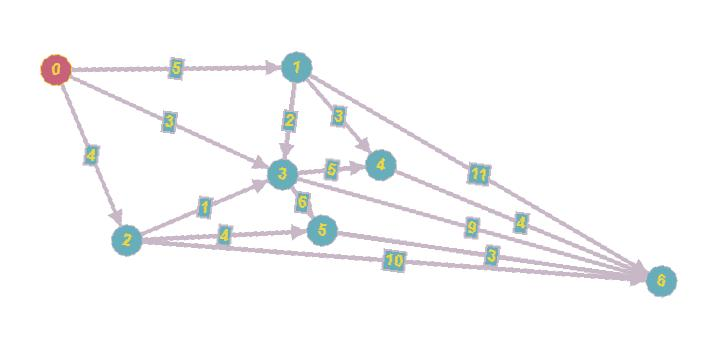

*Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
*Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [ ]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [ ]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [ ]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [ ]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta pasa por :")
print(calcular_ruta(RUTA, 0,6) )
print("Con valor" , PRECIOS[0][6])



La ruta pasa por :
0,2,5
Con valor 11


##Problema de Asignacion de tarea

In [ ]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [ ]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
    print("COSTES[",S[i],"][",i,"]: ", COSTES[S[i]][i], "VALOR: ", VALOR )
  return VALOR



valor((0, 1, 2, 3  ),COSTES)

COSTES[ 0 ][ 0 ]:  11 VALOR:  11
COSTES[ 1 ][ 1 ]:  15 VALOR:  26
COSTES[ 2 ][ 2 ]:  19 VALOR:  45
COSTES[ 3 ][ 3 ]:  28 VALOR:  73


73

In [ ]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [ ]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [ ]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [ ]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  print(COSTES) ##
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  print("Cota Superior:", CotaSup) ##

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    # print("Nodo prometedor:", nodo_prometedor) ##

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] ) ##
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

[[29 14 19 27 26 49]
 [11 29 19 39 41 29]
 [34 33 43 15 12 11]
 [39 13 16 20 23 12]
 [48 21 49 11 32 29]
 [29 27 22 35 44 27]]
COSTES[ 0 ][ 0 ]:  29 VALOR:  29
COSTES[ 1 ][ 1 ]:  29 VALOR:  58
COSTES[ 2 ][ 2 ]:  43 VALOR:  101
COSTES[ 3 ][ 3 ]:  20 VALOR:  121
COSTES[ 4 ][ 4 ]:  32 VALOR:  153
COSTES[ 5 ][ 5 ]:  27 VALOR:  180
Cota Superior: 180

********Soluciones: [{'s': (1, 0, 4, 5, 3, 2), 'ci': np.int64(82)}]

********Soluciones: [{'s': (1, 0, 4, 5, 2, 3), 'ci': np.int64(133)}]
La solucion final es: [{'s': (1, 0, 4, 5, 3, 2), 'ci': np.int64(82)}]  en  178  iteraciones  para dimension:  6


#### Comentarios:
- Para analizar el orden de complejidad tenemos para el primer trabajador $n$, por la poda,  para el segundo $n-1$ , el tercero es $n-3$, y así. Por lo tanto la complejidad es $O(n!)$
- Se realizaron varias pruebas, los tiempos se incrementaron progresivamente, al llegar a 10 el tiempo es considerable.
- Considero que no es recomendable más de 11.

In [ ]:
# Se realizan pruebas con otros valores, con valor 10 ya el tiempo es coxnsiderable

import numpy as np
COSTES = np.random.randint(10, 50, size=(10, 10))
ramificacion_y_poda(COSTES)

[[30 42 35 15 37 40 21 25 16 28]
 [15 36 27 25 29 21 36 18 21 22]
 [47 34 27 30 35 15 33 13 20 24]
 [29 22 23 14 22 22 36 41 21 26]
 [43 14 27 21 21 35 24 15 33 17]
 [11 49 40 31 26 49 10 29 27 39]
 [23 36 32 29 30 31 38 11 29 42]
 [49 49 30 40 32 37 45 32 25 36]
 [24 29 16 20 16 37 19 33 47 20]
 [43 11 31 19 10 31 23 20 10 33]]
COSTES[ 0 ][ 0 ]:  30 VALOR:  30
COSTES[ 1 ][ 1 ]:  36 VALOR:  66
COSTES[ 2 ][ 2 ]:  27 VALOR:  93
COSTES[ 3 ][ 3 ]:  14 VALOR:  107
COSTES[ 4 ][ 4 ]:  21 VALOR:  128
COSTES[ 5 ][ 5 ]:  49 VALOR:  177
COSTES[ 6 ][ 6 ]:  38 VALOR:  215
COSTES[ 7 ][ 7 ]:  32 VALOR:  247
COSTES[ 8 ][ 8 ]:  47 VALOR:  294
COSTES[ 9 ][ 9 ]:  33 VALOR:  327
Cota Superior: 327

********Soluciones: [{'s': (8, 0, 5, 3, 1, 6, 7, 2, 4, 9), 'ci': np.int64(174)}]

********Soluciones: [{'s': (8, 0, 5, 3, 1, 6, 7, 4, 2, 9), 'ci': np.int64(176)}]

********Soluciones: [{'s': (3, 0, 5, 4, 1, 6, 7, 8, 2, 9), 'ci': np.int64(176)}]

********Soluciones: [{'s': (8, 0, 5, 3, 9, 6, 7, 2, 4, 1), 'ci': n

##Descenso del gradiente

In [20]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide por le metodo del descenso del gradiente : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [21]:
#Definimos la funcion(f) y el gradiente(df)
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

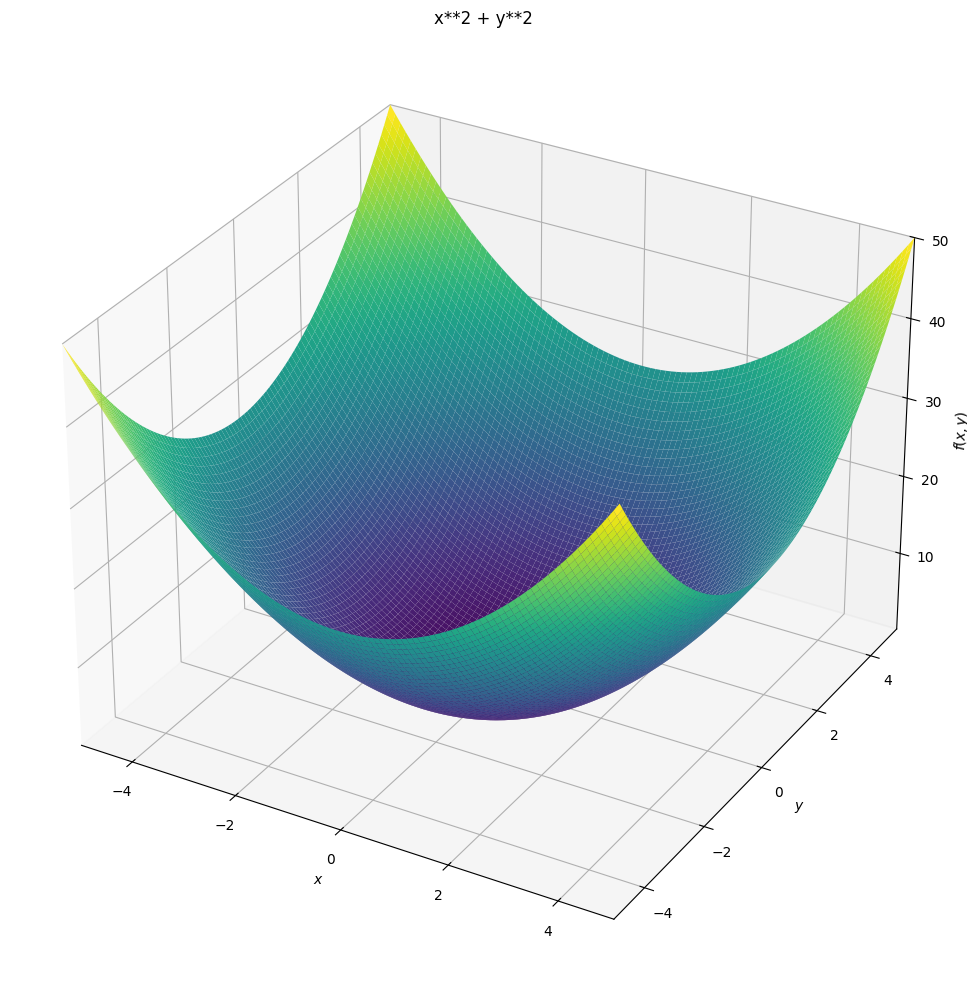

In [22]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

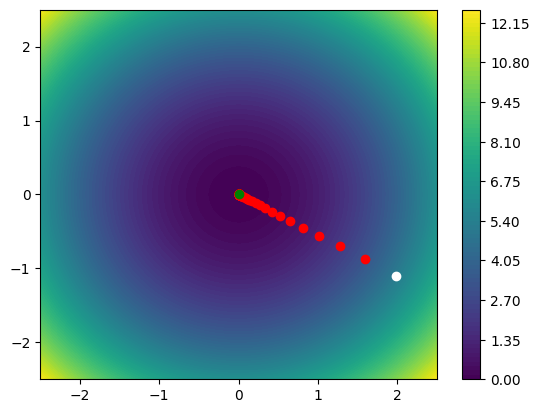

Solucion: [6.972288618433991e-49, -3.853050511236147e-49] 6.34588068208813e-97


In [27]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=2.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:500
for _ in range(500):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
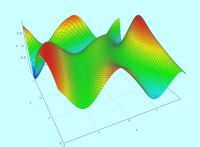


Se realizan las derivadas:
Para simplificar la derivación, se renombran temporalmente:
$$a = \frac{1}{2}x^2 - \frac{1}{4}y^2 + 3$$
$$b = 2x + 1 - e^y$$
 - Derivando respecto a $x$:
 $$\frac{\partial f}{\partial x} = \frac{\partial}{\partial x}(\sin a) \cdot \cos b + \sin a \cdot \frac{\partial}{\partial x}(\cos b)$$


 $$\frac{\partial f}{\partial x} = [\cos(a) \cdot \frac{\partial a}{\partial x}] \cdot \cos(b) + \sin(a) \cdot [-\sin(b) \cdot \frac{\partial b}{\partial x}]$$

 Condiderando:
 $$\frac{\partial a}{\partial x} = x$$
$$\frac{\partial b}{\partial x} = 2$$
Entonces:
 $$\frac{\partial f}{\partial x} = [\cos(a) \cdot x] \cdot \cos(b) + \sin(a) \cdot [-\sin(b) \cdot 2]$$
 $$\frac{\partial f}{\partial x} = x \cos(a)\cos(b) - 2 \sin(a)\sin(b)$$
Reemplazando:
$$x \cos\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \cos(2x + 1 - e^y) - 2 \sin\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \sin(2x + 1 - e^y)$$

<br>
 - Derivando respecto a $y$:

$$\frac{\partial f}{\partial y} = \frac{\partial a}{\partial y} \cos(a)\cos(b) - \frac{\partial b}{\partial y} \sin(a)\sin(b)$$

Considerando:
$$\frac{\partial a}{\partial y} = -\frac{1}{2}y$$
$$\frac{\partial b}{\partial y} = -e^y$$

Entonces:

$$\frac{\partial f}{\partial y} = [(-\frac{1}{2}y) \cdot \cos(a)] \cdot \cos(b) - (-e^y) \cdot [\sin(b) \cdot \sin(a)]$$

$$\frac{\partial f}{\partial y} = -\frac{1}{2}y \cos(a)\cos(b) + e^y \sin(a)\sin(b)$$

Reemplazando:
$$-\frac{1}{2}y \cos\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \cos(2x + 1 - e^y) + e^y \sin\left(\frac{1}{2}x^2 - \frac{1}{4}y^2 + 3\right) \sin(2x + 1 - e^y)$$





In [138]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )
# df = lambda X: [2*X[0] , 2*X[1]]
df = lambda x: np.array([
    # x
    x[0] * np.cos(0.5 * x[0]**2 - 0.25 * x[1]**2 + 3) * np.cos(2 * x[0] + 1 - np.exp(x[1])) -
    2 * np.sin(0.5 * x[0]**2 - 0.25 * x[1]**2 + 3) * np.sin(2 * x[0] + 1 - np.exp(x[1])),
    # y
    -0.5 * x[1] * np.cos(0.5 * x[0]**2 - 0.25 * x[1]**2 + 3) * np.cos(2 * x[0] + 1 - np.exp(x[1])) +
    np.exp(x[1]) * np.sin(0.5 * x[0]**2 - 0.25 * x[1]**2 + 3) * np.sin(2 * x[0] + 1 - np.exp(x[1]))
])

df([1,2])

array([-0.88037456,  3.93845025])

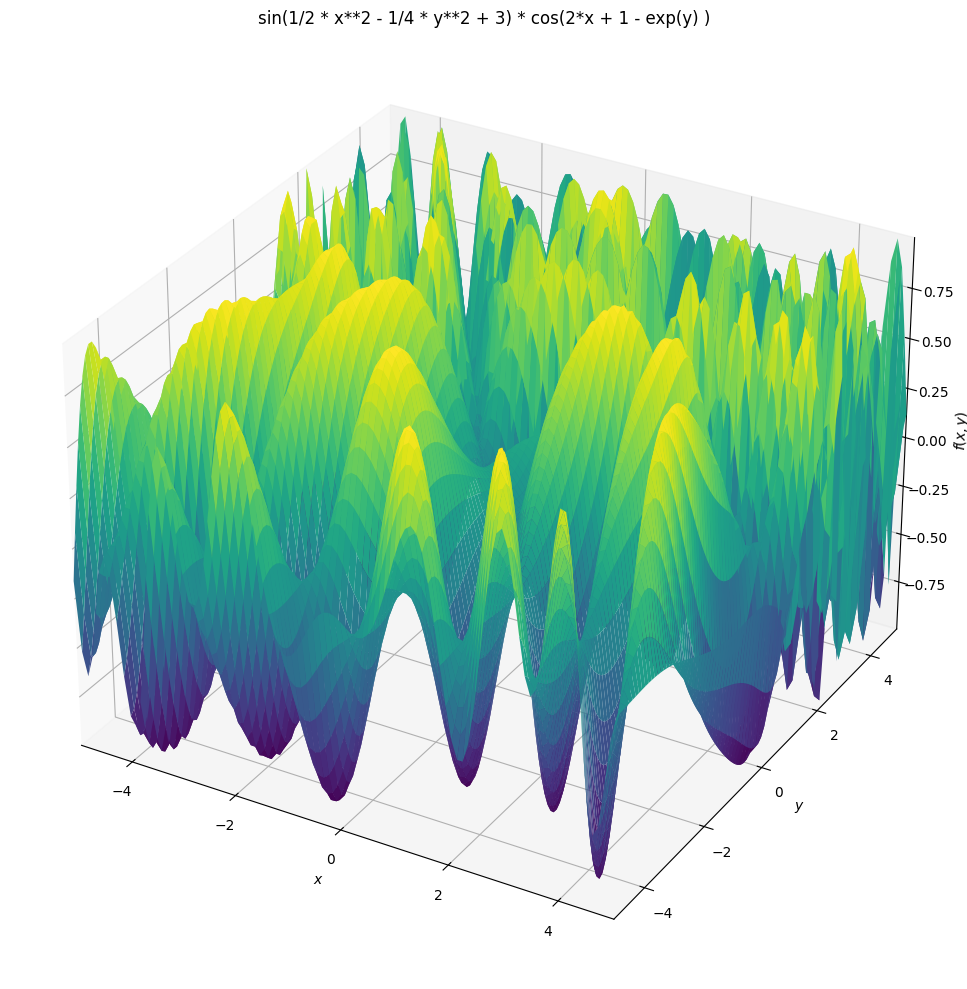

In [139]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
from sympy import symbols, sin, cos, exp
x,y = symbols('x y')
# plot3d(x**2 + y**2,
plot3d( sin(1/2 * x**2 - 1/4 * y**2 + 3) * cos(2*x + 1 - exp(y) ),
      #  (x,-5,5),(y,-5,5),
       (x,-5,5),(y,-5,5), #Se modifica el rango para que se parezca a al ejemplo
       title='sin(1/2 * x**2 - 1/4 * y**2 + 3) * cos(2*x + 1 - exp(y) )',
       size=(10,10))

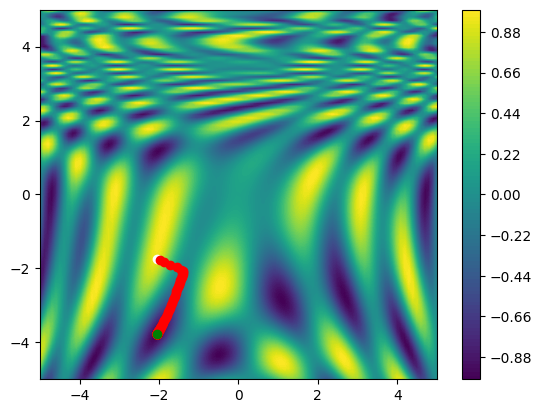

Solucion: [np.float64(-2.059247202821749), np.float64(-3.767998510811649)] -1.0


In [151]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
# rango=2.5
rango=5 # Se moidifica la imagen porque los valores tienden a salir de la gráfica

X=np.linspace(-rango,rango,resolucion)
# X=np.linspace(-0,rango,resolucion)
# Y=np.linspace(-0,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
# P=[random.uniform(-2,2  ),random.uniform(-2,2 ) ]
P=[random.uniform(-2.5,2.5),random.uniform(-2.5,2.5 ) ] # se reduce el rango para consistencia de la imagen
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:500
for _ in range(5000):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))

##Problema de Autobuses por Fuerza Bruta

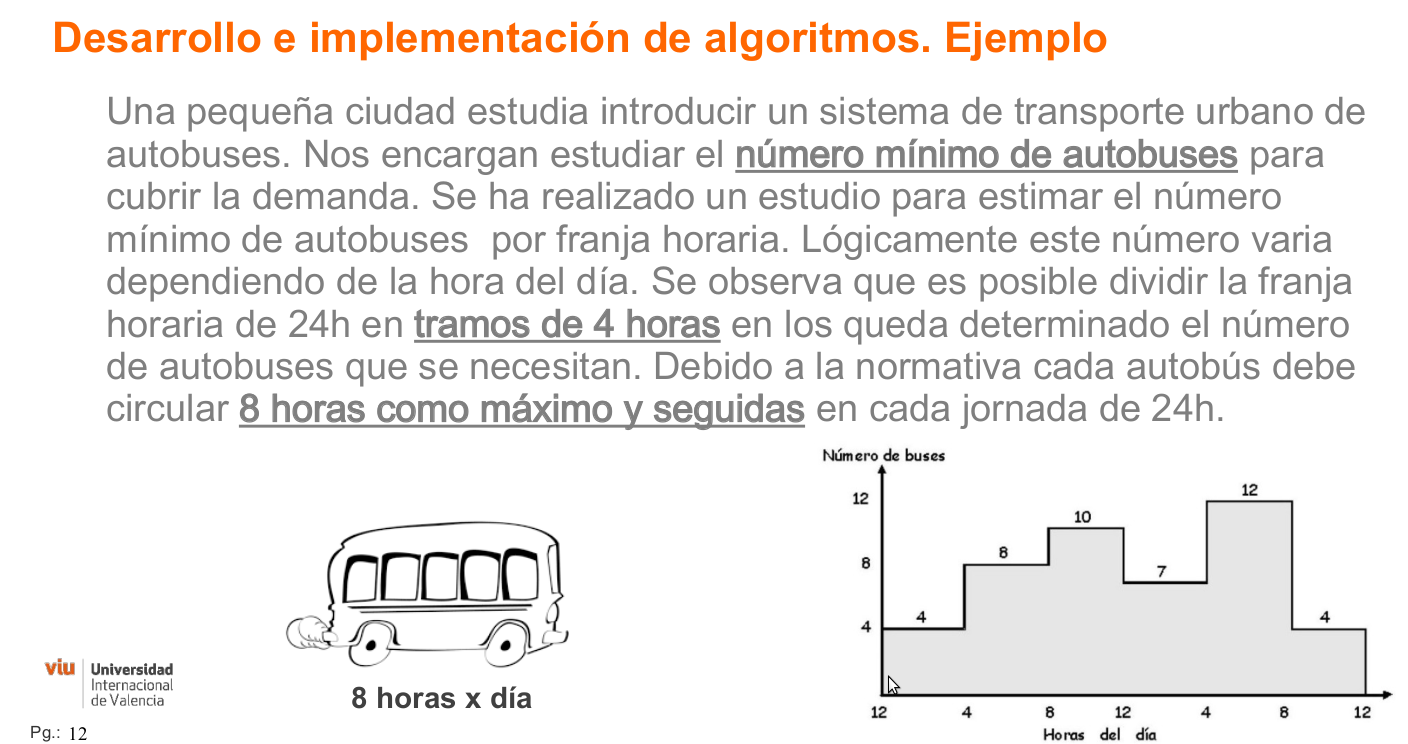

In [133]:
###################################################
# Ximo Sanz Tornero.
###################################################
from itertools import product

# Paso 1: Inicializamos los datos
# Demanda mínima de autobuses por tramo
demanda = [4, 8, 10, 7, 12, 4]  # d[0], d[1], ..., d[5]
tramos = len(demanda)  # Número de tramos (6 en este caso)


#Posible Solucion
x = [4,5,6,7,8,9]

for t in range(tramos):
    # Calculamos el número actual de autobuses que están cubriendo el tramo t
    cobertura_actual = x[t] + x[t - 1]  # Autobuses en t y t-1 (cíclico)

    # Si la cobertura actual es menor que la demanda, añadimos autobuses en t
    if cobertura_actual < demanda[t]:
        # Añadimos los autobuses necesarios en el tramo t
        x[t] += demanda[t] - cobertura_actual

#Función objetivo
f_objetivo = sum(x)


# Se crean funciones tanto para verificar posibles soluciones como para obtener el valor de la función objetivo de la solución
# Función objetivo: suma de todos los x[i]
def funcion_objetivo(solucion):
    return sum(solucion)

# Verificación de restricciones
def verifica_restricciones(solucion):
    for t in range(tramos):
        # Se calcula el número actual de autobuses que están cubriendo el tramo t
        cobertura_actual = solucion[t] + solucion[t - 1]  # Cíclico
        if cobertura_actual < demanda[t]:
            return False
    return True


# Se realiza el algoritmo por fuerza bruta con todas las posibles combinaciones de valores que tenemos en funcion de la variable demanda
# Generación del espacio de soluciones
# Para ver mejor el funcionamiento, ejecutar: for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)
espacio_soluciones = product(*(range(d + 1) for d in demanda))

# Búsqueda de la mejor solución
mejor_valor_objetivo = float('inf')
mejores_soluciones = []

for solucion in espacio_soluciones:
    if verifica_restricciones(solucion):
        valor_objetivo = funcion_objetivo(solucion)
        if valor_objetivo < mejor_valor_objetivo:
            mejor_valor_objetivo = valor_objetivo
            mejores_soluciones = [solucion]
        elif valor_objetivo == mejor_valor_objetivo:
            mejores_soluciones.append(solucion)  # Agrega soluciones con el mismo valor

# Resultado
print("Mejores soluciones:")
for solucion in mejores_soluciones:
    print(solucion)
print("Valor mínimo de la función objetivo:", mejor_valor_objetivo)



Mejores soluciones:
(0, 8, 2, 5, 7, 4)
(0, 8, 2, 6, 6, 4)
(0, 8, 2, 7, 5, 4)
(1, 7, 3, 4, 8, 3)
(1, 7, 3, 5, 7, 3)
(1, 7, 3, 6, 6, 3)
(1, 7, 3, 7, 5, 3)
(1, 8, 2, 5, 7, 3)
(1, 8, 2, 6, 6, 3)
(1, 8, 2, 7, 5, 3)
(2, 6, 4, 3, 9, 2)
(2, 6, 4, 4, 8, 2)
(2, 6, 4, 5, 7, 2)
(2, 6, 4, 6, 6, 2)
(2, 6, 4, 7, 5, 2)
(2, 7, 3, 4, 8, 2)
(2, 7, 3, 5, 7, 2)
(2, 7, 3, 6, 6, 2)
(2, 7, 3, 7, 5, 2)
(2, 8, 2, 5, 7, 2)
(2, 8, 2, 6, 6, 2)
(2, 8, 2, 7, 5, 2)
(3, 5, 5, 2, 10, 1)
(3, 5, 5, 3, 9, 1)
(3, 5, 5, 4, 8, 1)
(3, 5, 5, 5, 7, 1)
(3, 5, 5, 6, 6, 1)
(3, 5, 5, 7, 5, 1)
(3, 6, 4, 3, 9, 1)
(3, 6, 4, 4, 8, 1)
(3, 6, 4, 5, 7, 1)
(3, 6, 4, 6, 6, 1)
(3, 6, 4, 7, 5, 1)
(3, 7, 3, 4, 8, 1)
(3, 7, 3, 5, 7, 1)
(3, 7, 3, 6, 6, 1)
(3, 7, 3, 7, 5, 1)
(3, 8, 2, 5, 7, 1)
(3, 8, 2, 6, 6, 1)
(3, 8, 2, 7, 5, 1)
(4, 4, 6, 1, 11, 0)
(4, 4, 6, 2, 10, 0)
(4, 4, 6, 3, 9, 0)
(4, 4, 6, 4, 8, 0)
(4, 4, 6, 5, 7, 0)
(4, 4, 6, 6, 6, 0)
(4, 4, 6, 7, 5, 0)
(4, 5, 5, 2, 10, 0)
(4, 5, 5, 3, 9, 0)
(4, 5, 5, 4, 8, 0)
(4, 5, 5, 5, 7, 0)
(4, 5, 

In [134]:
for solucion in product(*(range(d + 1) for d in [1,2,3])):   print(solucion)

(0, 0, 0)
(0, 0, 1)
(0, 0, 2)
(0, 0, 3)
(0, 1, 0)
(0, 1, 1)
(0, 1, 2)
(0, 1, 3)
(0, 2, 0)
(0, 2, 1)
(0, 2, 2)
(0, 2, 3)
(1, 0, 0)
(1, 0, 1)
(1, 0, 2)
(1, 0, 3)
(1, 1, 0)
(1, 1, 1)
(1, 1, 2)
(1, 1, 3)
(1, 2, 0)
(1, 2, 1)
(1, 2, 2)
(1, 2, 3)
